In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
file_path = 'dataset_A_news_full_10500.csv'
df = pd.read_csv(file_path)

# 데이터 기본 정보 확인
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   title                       10500 non-null  object
 1   link                        10500 non-null  object
 2   date                        10500 non-null  object
 3   source                      10500 non-null  object
 4   number_of_characters_title  10500 non-null  int64 
 5   number_of_words_title       10500 non-null  int64 
 6   day_of_week                 10500 non-null  object
 7   month                       10500 non-null  object
 8   year                        10500 non-null  int64 
 9   quarter                     10500 non-null  int64 
 10  is_weekend                  10500 non-null  bool  
 11  classes_str                 10500 non-null  object
dtypes: bool(1), int64(4), object(7)
memory usage: 912.7+ KB
None


,title,link,date,source,number_of_characters_title,number_of_words_title,day_of_week,month,year,quarter,is_weekend,classes_str
0,Google’s AI is the ‘worst’ for stealing conten...,https://news.google.com/rss/articles/CBMipgFBV...,2025-09-11,Fortune,74,13,Thursday,September,2025,3,False,Sentiment (Positive / Negative Feelings); Huma...
1,Powering the Next Wave of Enterprise Innovatio...,https://news.google.com/rss/articles/CBMitgFBV...,2025-09-11,Silicon Canals,106,16,Thursday,September,2025,3,False,"Creativity, Expression & Identity; Work, Jobs ..."
2,AI a ‘strategic necessity’ law lecturer says,https://news.google.com/rss/articles/CBMiiAFBV...,2025-09-11,qlsproctor.com.au,64,9,Thursday,September,2025,3,False,"Society, Ethics & Culture"
3,Datacom sees AI agents as pivotal to legacy ap...,https://news.google.com/rss/articles/CBMirAFBV...,2025-09-11,ARNnet,70,12,Thursday,September,2025,3,False,"Routine, Lifestyle & Behavior"
4,"Student Blog: Startups, AI, and Lessons from S...",https://news.google.com/rss/articles/CBMijwFBV...,2025-09-11,The University of Queensland,85,13,Thursday,September,2025,3,False,"Learning, Knowledge & Education"


C:\Users\zxcvz\AppData\Local\Temp\ipykernel_11468\2837613491.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quarter', palette='viridis')


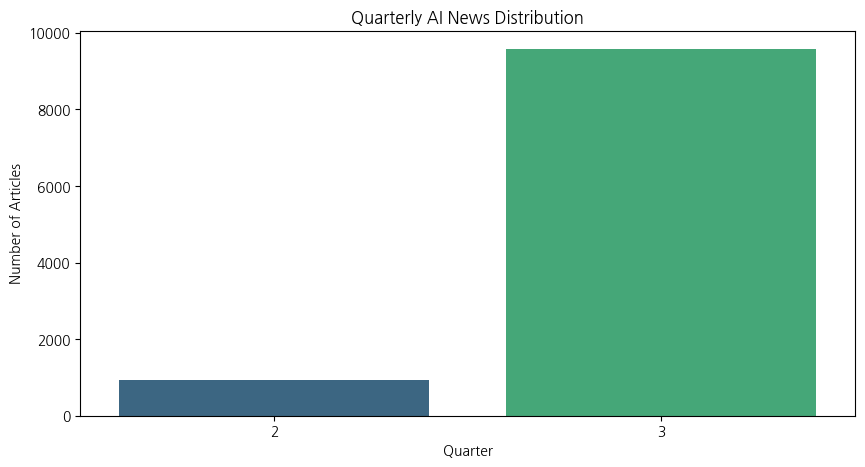

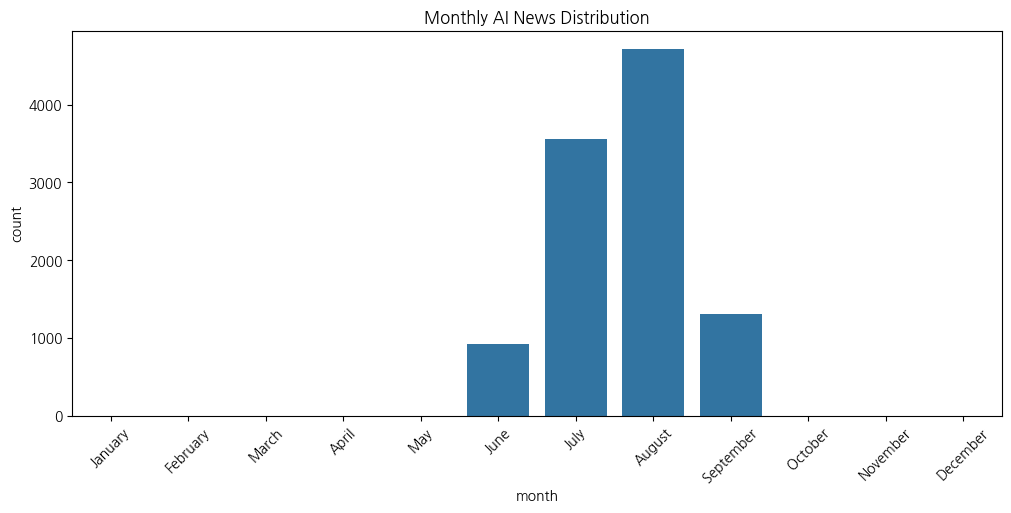

In [3]:
# 분기별 기사 수 시각화
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='quarter', palette='viridis')
plt.title('Quarterly AI News Distribution')
plt.xlabel('Quarter')
plt.ylabel('Number of Articles')
plt.show()

# 월별 기사 수 추이
plt.figure(figsize=(12, 5))
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data=df, x='month', order=month_order)
plt.xticks(rotation=45)
plt.title('Monthly AI News Distribution')
plt.show()

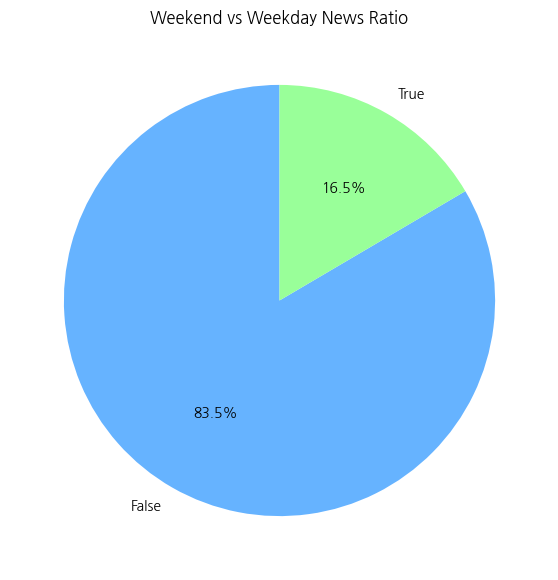

In [4]:
plt.figure(figsize=(7, 7))
df['is_weekend'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Weekend vs Weekday News Ratio')
plt.ylabel('')
plt.show()

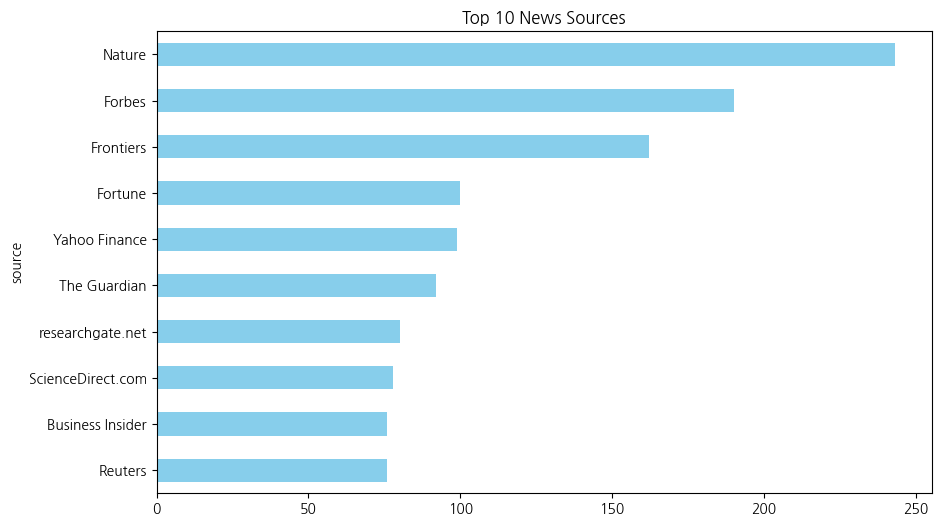

In [9]:
# top 10 news
plt.figure(figsize=(10, 6))
df['source'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 News Sources')
plt.gca().invert_yaxis()
plt.show()

C:\Users\zxcvz\AppData\Local\Temp\ipykernel_11468\1830325304.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


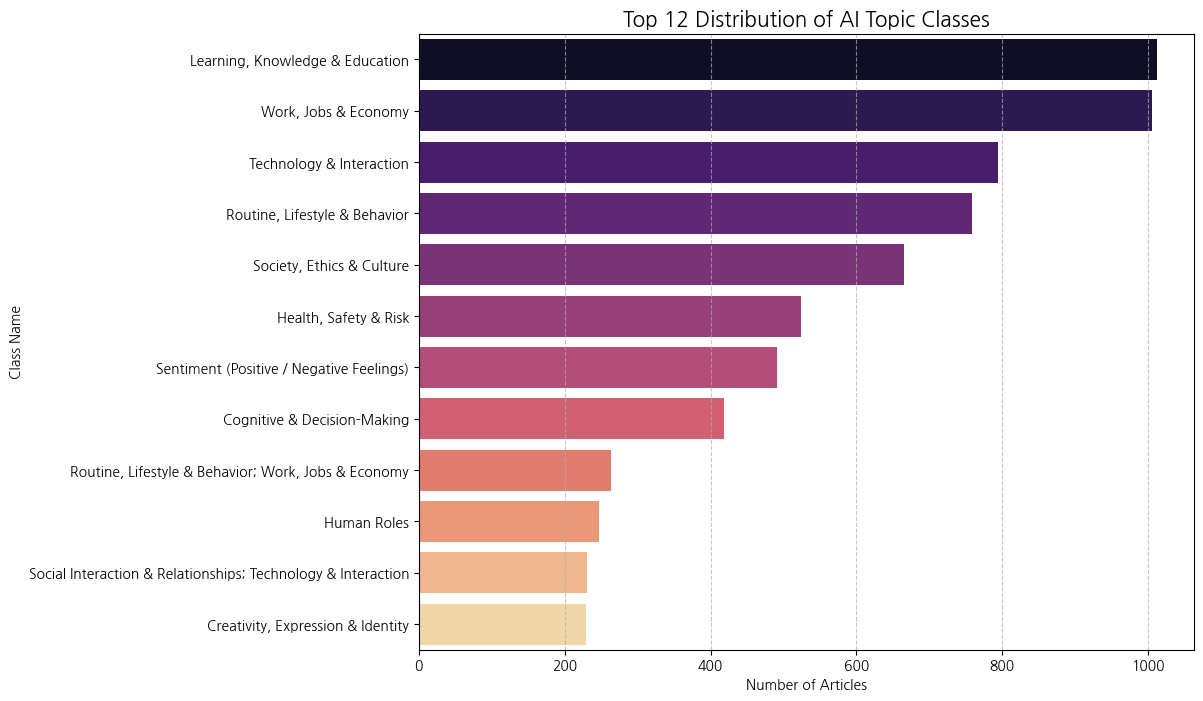

In [10]:
# 상위 12개 클래스 추출
top_12_classes = df['classes_str'].value_counts().head(12).index

# 상위 12개 데이터만 필터링
df_top12 = df[df['classes_str'].isin(top_12_classes)]

# 시각화 (figsize를 가로로 넓히고 세로를 줄여서 가독성을 높였습니다)
plt.figure(figsize=(10, 8))
sns.countplot(
    data=df_top12, 
    y='classes_str', 
    order=top_12_classes,
    palette='magma' # 색상을 입히면 구분이 더 쉽습니다
)

plt.title('Top 12 Distribution of AI Topic Classes', fontsize=15)
plt.xlabel('Number of Articles')
plt.ylabel('Class Name')
plt.grid(axis='x', linestyle='--', alpha=0.7) # 수치 파악을 위한 그리드 추가
plt.show()

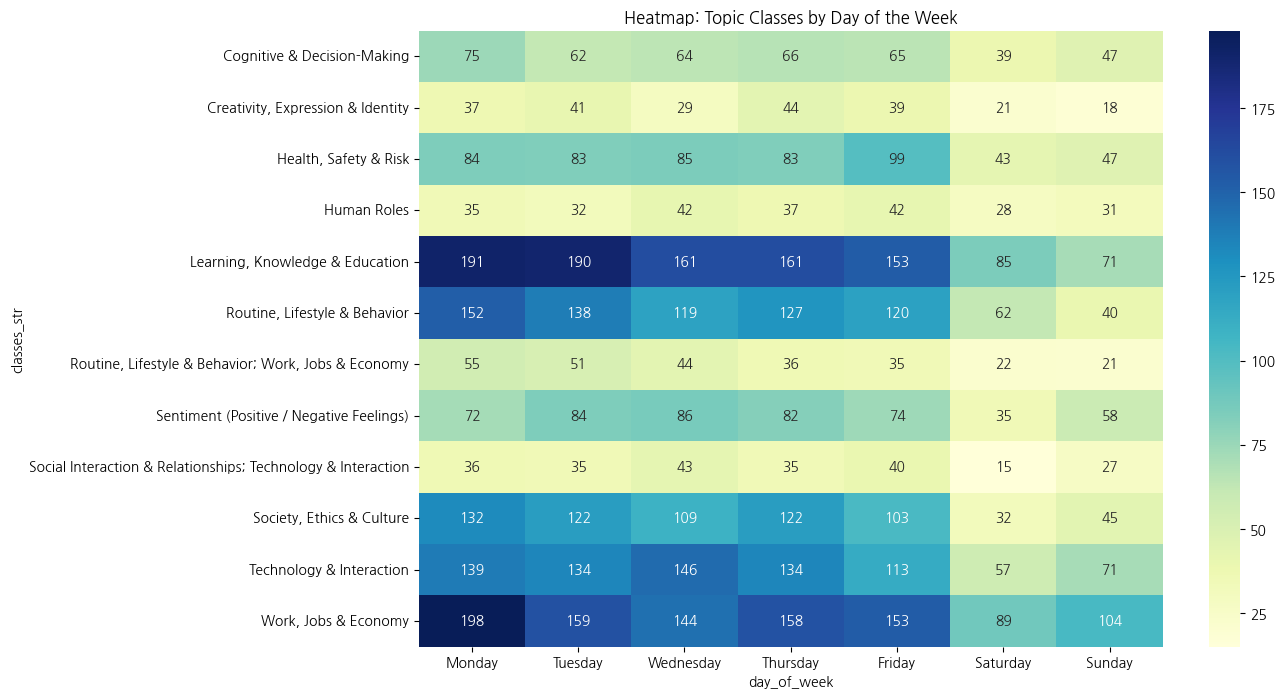

In [11]:
# 요일과 클래스 간의 관계를 보여주는 피벗 테이블 생성
# 위에서 만든 top_12_classes를 활용합니다.
pivot_df = df[df['classes_str'].isin(top_12_classes)].pivot_table(
    index='classes_str', 
    columns='day_of_week', 
    values='title', 
    aggfunc='count'
).fillna(0)

# 요일 순서 정렬
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_df = pivot_df.reindex(columns=days)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Heatmap: Topic Classes by Day of the Week')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# ... 나머지 코드는 동일합니다 ...

# 1. 데이터 준비 (결측치 제거)
df_nlp = df.dropna(subset=['title', 'classes_str'])

# 상위 12개 클래스만 사용 (데이터 불균형 해소)
top_12 = df_nlp['classes_str'].value_counts().head(12).index
df_nlp = df_nlp[df_nlp['classes_str'].isin(top_12)]

X = df_nlp['title']
y = df_nlp['classes_str']

# 2. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 텍스트 벡터화 (TF-IDF)
# 영문 뉴스 기준이므로 stop_words='english' 설정
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 4. 모델 학습 (Random Forest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_tfidf, y_train)

# 5. 예측 및 평가
y_pred = clf.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n[Classification Report]")
print(classification_report(y_test, y_pred))

Accuracy: 0.9661

[Classification Report]
                                                              precision    recall  f1-score   support

                                 Cognitive & Decision-Making       0.99      0.97      0.98        78
                           Creativity, Expression & Identity       1.00      0.92      0.96        50
                                       Health, Safety & Risk       0.99      0.98      0.99       118
                                                 Human Roles       0.98      0.98      0.98        59
                             Learning, Knowledge & Education       0.96      0.99      0.98       204
                               Routine, Lifestyle & Behavior       0.96      0.96      0.96       155
         Routine, Lifestyle & Behavior; Work, Jobs & Economy       1.00      0.71      0.83        55
                    Sentiment (Positive / Negative Feelings)       0.92      0.94      0.93        94
Social Interaction & Relationships; Tec